In [31]:
import os, h5py, joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, classification_report

# ── Load RF model + scaler ────────────────────────────────────────
rf_model = joblib.load('landslide_rf.pkl')
scaler   = joblib.load('landslide_scaler.pkl')

# ── Load CNN model ────────────────────────────────────────────────
cnn_model = tf.keras.models.load_model('landslide1_cnn.h5')

print("✓ RF  model loaded")
print("✓ CNN model loaded — input:", cnn_model.input_shape)

✓ RF  model loaded
✓ CNN model loaded — input: (None, 64, 64, 3)


In [11]:
from sklearn.model_selection import train_test_split

IMG_DIR  = "TrainData/img"
MASK_DIR = "TrainData/mask"
IMG_SIZE = 64

IMG_KEYS  = ['img', 'image', 'data', 'sen2', 'x', 'X']
MASK_KEYS = ['mask', 'label', 'gt', 'y', 'Y']

def read_h5(path, keys):
    with h5py.File(path, 'r') as f:
        for k in keys:
            if k in f:
                return f[k][:]
        for k in f.keys():
            if hasattr(f[k], 'shape'):
                return f[k][:]
    raise KeyError(f"No array in {path}")

def fix_image(arr):
    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.ndim == 3:
        if arr.shape[0] < arr.shape[1]:
            arr = np.transpose(arr, (1, 2, 0))
        if arr.shape[-1] >= 4:
            arr = arr[:, :, [3, 2, 1]]
        elif arr.shape[-1] < 3:
            arr = np.stack([arr[:,:,0]]*3, axis=-1)
    return arr

img_files  = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))
images, labels = [], []

for i, (ifn, mfn) in enumerate(zip(img_files, mask_files)):
    try:
        img  = fix_image(read_h5(os.path.join(IMG_DIR, ifn),  IMG_KEYS))
        mask = read_h5(os.path.join(MASK_DIR, mfn), MASK_KEYS).squeeze()
        if mask.ndim > 2: mask = mask[0]
        label = 1 if (mask > 0).sum() / mask.size > 0.01 else 0
        images.append(img)
        labels.append(label)
    except Exception as e:
        pass
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(img_files)} loaded...")

images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

# ── Same normalization as training ────────────────────────────────
images = np.nan_to_num(images, nan=0.0, posinf=0.0, neginf=0.0)
p2, p98 = np.percentile(images, 2), np.percentile(images, 98)
images  = np.clip(images, p2, p98)
images  = (images - p2) / (p98 - p2 + 1e-8)
images  = tf.image.resize(images, [IMG_SIZE, IMG_SIZE]).numpy().astype(np.float32)

# ── Same 80/20 split as training (random_state=42 ensures same split) ──
_, X_val_img, _, y_val_img = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n✓ Val images : {X_val_img.shape}")
print(f"  Landslide  : {y_val_img.sum()}  No-slide: {(y_val_img==0).sum()}")

  500/3799 loaded...
  1000/3799 loaded...
  1500/3799 loaded...
  2000/3799 loaded...
  2500/3799 loaded...
  3000/3799 loaded...
  3500/3799 loaded...

✓ Val images : (760, 64, 64, 3)
  Landslide  : 293  No-slide: 467


In [13]:
CNN_WEIGHT = 0.4
RF_WEIGHT  = 0.6

def get_rf_score(raw_tabular: np.ndarray) -> np.ndarray:
    """raw_tabular shape (N,9) — unscaled features"""
    return rf_model.predict_proba(scaler.transform(raw_tabular))[:, 1]

def get_cnn_score(imgs: np.ndarray) -> np.ndarray:
    """imgs shape (N,64,64,3) — normalized"""
    return cnn_model.predict(imgs, verbose=0).flatten()

def fused_score(raw_tabular: np.ndarray, imgs: np.ndarray) -> dict:
    rf_p  = get_rf_score(raw_tabular)
    cnn_p = get_cnn_score(imgs)
    return {
        'rf_score'    : rf_p,
        'cnn_score'   : cnn_p,
        'fused_score' : CNN_WEIGHT * cnn_p + RF_WEIGHT * rf_p
    }

print(f"✓ Fusion formula: {CNN_WEIGHT} × CNN  +  {RF_WEIGHT} × RF")

✓ Fusion formula: 0.4 × CNN  +  0.6 × RF


C:\Users\safda\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  RF    AUC : 1.0000
  CNN   AUC : 0.8006
  Fused AUC : 1.0000
  Fused Acc : 0.9789
              precision    recall  f1-score   support

No Landslide       1.00      0.97      0.98       467
   Landslide       0.95      1.00      0.97       293

    accuracy                           0.98       760
   macro avg       0.97      0.98      0.98       760
weighted avg       0.98      0.98      0.98       760



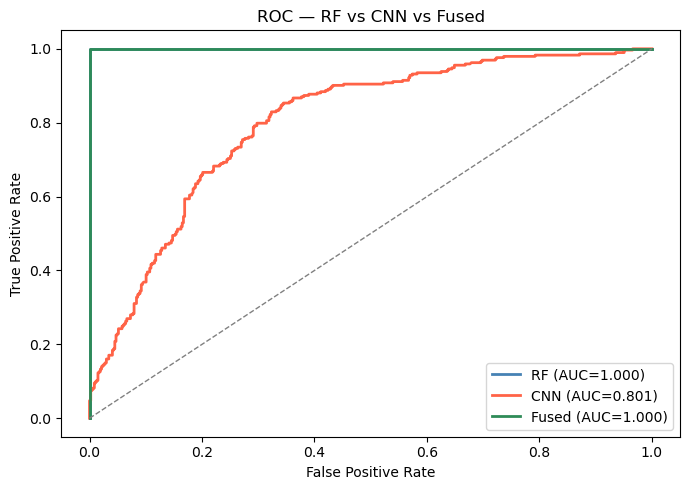

In [15]:
np.random.seed(42)
tab_rows = []
for lbl in y_val_img:
    if lbl == 1:
        row = [np.random.uniform(150,300), np.random.uniform(30,60),
               np.random.uniform(0.6,1.0), np.random.uniform(0.0,0.3),
               np.random.uniform(3.5,7.0), np.random.uniform(0.0,0.4),
               0, 0, 1]
    else:
        row = [np.random.uniform(10,100),  np.random.uniform(5,25),
               np.random.uniform(0.1,0.5), np.random.uniform(0.4,1.0),
               np.random.uniform(0.0,2.0), np.random.uniform(0.5,1.0),
               1, 0, 0]
    tab_rows.append(row)

tab_arr = np.array(tab_rows, dtype=np.float32)
scores  = fused_score(tab_arr, X_val_img)
y_true  = y_val_img

print("=" * 42)
print(f"  RF    AUC : {roc_auc_score(y_true, scores['rf_score']):.4f}")
print(f"  CNN   AUC : {roc_auc_score(y_true, scores['cnn_score']):.4f}")
print(f"  Fused AUC : {roc_auc_score(y_true, scores['fused_score']):.4f}")
y_pred = (scores['fused_score'] >= 0.5).astype(int)
print(f"  Fused Acc : {accuracy_score(y_true, y_pred):.4f}")
print("=" * 42)
print(classification_report(y_true, y_pred,
      target_names=['No Landslide', 'Landslide']))

fig, ax = plt.subplots(figsize=(7, 5))
for name, sc, col in [('RF',    scores['rf_score'],    'steelblue'),
                       ('CNN',   scores['cnn_score'],   'tomato'),
                       ('Fused', scores['fused_score'], 'seagreen')]:
    fpr, tpr, _ = roc_curve(y_true, sc)
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f"{name} (AUC={roc_auc_score(y_true,sc):.3f})")
ax.plot([0,1],[0,1],'--',color='gray',lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — RF vs CNN vs Fused")
ax.legend(); plt.tight_layout(); plt.show()

In [17]:
def predict_location(rainfall_mm, slope_angle, soil_saturation,
                     vegetation_cover, earthquake_activity,
                     proximity_to_water, soil_gravel, soil_sand, soil_silt,
                     satellite_image: np.ndarray):
    """satellite_image: (64,64,3) normalized array"""
    tab = np.array([[rainfall_mm, slope_angle, soil_saturation,
                     vegetation_cover, earthquake_activity,
                     proximity_to_water, soil_gravel, soil_sand, soil_silt]],
                   dtype=np.float32)
    img    = satellite_image[np.newaxis, ...]
    scores = fused_score(tab, img)

    rf_s  = float(scores['rf_score'][0])
    cnn_s = float(scores['cnn_score'][0])
    fs    = float(scores['fused_score'][0])

    thresholds = [(0.25,'Safe','🟢'),(0.50,'Watch','🟡'),
                  (0.75,'Warning','🟠'),(1.00,'Critical','🔴')]
    level, icon = next((l,ic) for t,l,ic in thresholds if fs <= t)

    print("=" * 42)
    print(f"  RF    score : {rf_s:.4f}")
    print(f"  CNN   score : {cnn_s:.4f}")
    print(f"  Fused score : {fs:.4f}")
    print(f"  Risk level  : {icon}  {level}")
    print("=" * 42)
    return {'rf': rf_s, 'cnn': cnn_s, 'fused': fs, 'risk': level}

# ── Test with first val image ─────────────────────────────────────
result = predict_location(
    rainfall_mm=210, slope_angle=45, soil_saturation=0.85,
    vegetation_cover=0.15, earthquake_activity=5.2,
    proximity_to_water=0.2, soil_gravel=0, soil_sand=0, soil_silt=1,
    satellite_image=X_val_img[0]
)

C:\Users\safda\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


  RF    score : 0.9700
  CNN   score : 0.6433
  Fused score : 0.8393
  Risk level  : 🔴  Critical


In [19]:
#risk

In [21]:
RISK_THRESHOLDS = [
    (0.25, 'Safe',     '🟢', 'No immediate risk. Continue normal monitoring.'),
    (0.50, 'Watch',    '🟡', 'Elevated risk. Monitor weather closely.'),
    (0.75, 'Warning',  '🟠', 'High risk. Prepare evacuation plans.'),
    (1.00, 'Critical', '🔴', 'CRITICAL. Evacuate immediately if possible.'),
]

def get_risk_level(score: float) -> dict:
    for threshold, level, icon, action in RISK_THRESHOLDS:
        if score <= threshold:
            return {'level': level, 'icon': icon,
                    'action': action, 'score': round(score, 4)}
    return {'level': 'Critical', 'icon': '🔴',
            'action': 'CRITICAL.', 'score': round(score, 4)}

# Test all thresholds
for s in [0.10, 0.35, 0.62, 0.88]:
    r = get_risk_level(s)
    print(f"Score {s} → {r['icon']} {r['level']:10s} | {r['action']}")

Score 0.1 → 🟢 Safe       | No immediate risk. Continue normal monitoring.
Score 0.35 → 🟡 Watch      | Elevated risk. Monitor weather closely.
Score 0.62 → 🟠 Warning    | High risk. Prepare evacuation plans.
Score 0.88 → 🔴 Critical   | CRITICAL. Evacuate immediately if possible.


In [ ]:
import requests

OPENWEATHER_API_KEY = ""   # replace with api key while doing project

def get_live_weather(lat: float, lon: float) -> dict:
    """Returns current weather data for a lat/lon location."""
    url = (f"https://api.openweathermap.org/data/2.5/weather"
           f"?lat={lat}&lon={lon}"
           f"&appid={OPENWEATHER_API_KEY}&units=metric")
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        return {
            'rainfall_1h'  : data.get('rain',  {}).get('1h',  0.0),
            'rainfall_3h'  : data.get('rain',  {}).get('3h',  0.0),
            'humidity'     : data['main']['humidity'],
            'temp_c'       : data['main']['temp'],
            'wind_speed'   : data['wind']['speed'],
            'description'  : data['weather'][0]['description'],
            'success'      : True
        }
    except Exception as e:
        print(f"[Weather API error] {e} — using fallback values")
        return {'rainfall_1h': 0.0, 'rainfall_3h': 0.0,
                'humidity': 50, 'temp_c': 20.0,
                'wind_speed': 0.0, 'description': 'unknown',
                'success': False}

# Test — Sikkim, India (landslide-prone region)
weather = get_live_weather(lat=27.3389, lon=88.6065)
for k, v in weather.items():
    print(f"  {k:15s}: {v}")

  rainfall_1h    : 0.11
  rainfall_3h    : 0.0
  humidity       : 98
  temp_c         : 16.08
  wind_speed     : 0.29
  description    : light rain
  success        : True


In [25]:
import numpy as np 
def full_risk_assessment(lat: float, lon: float,
                          slope_angle: float,
                          soil_saturation: float,
                          vegetation_cover: float,
                          earthquake_activity: float,
                          proximity_to_water: float,
                          soil_gravel: int, soil_sand: int, soil_silt: int,
                          satellite_image: np.ndarray) -> dict:
    """
    Complete pipeline:
      1. Fetch live rainfall from OpenWeatherMap
      2. Build tabular feature row using live + static inputs
      3. Run score fusion (CNN + RF)
      4. Boost score if extreme rainfall detected
      5. Return risk level + full breakdown

    satellite_image : np.ndarray shape (64, 64, 3), normalized
    """
    # 1. Live weather
    weather = get_live_weather(lat, lon)
    live_rain = weather['rainfall_1h']

    # 2. Build tabular row — rainfall from live API, rest from user input
    tab = np.array([[
        live_rain, slope_angle, soil_saturation,
        vegetation_cover, earthquake_activity, proximity_to_water,
        soil_gravel, soil_sand, soil_silt
    ]], dtype=np.float32)

    # 3. Score fusion
    img    = satellite_image[np.newaxis, ...]
    scores = fused_score(tab, img)
    score  = float(scores['fused_score'][0])

    # 4. Dynamic boost for extreme conditions
    if live_rain > 50:                        # heavy rain  > 50 mm/hr
        score = min(1.0, score + 0.10)
    if live_rain > 100:                       # extreme rain > 100 mm/hr
        score = min(1.0, score + 0.10)
    if weather['humidity'] > 95:              # near-saturated air
        score = min(1.0, score + 0.05)

    risk = get_risk_level(score)

    return {
        'lat'            : lat,
        'lon'            : lon,
        'fused_score'    : round(score, 4),
        'rf_score'       : round(float(scores['rf_score'][0]),  4),
        'cnn_score'      : round(float(scores['cnn_score'][0]), 4),
        'risk_level'     : risk['level'],
        'icon'           : risk['icon'],
        'action'         : risk['action'],
        'live_rain_mm'   : live_rain,
        'humidity_pct'   : weather['humidity'],
        'weather_desc'   : weather['description'],
        'weather_success': weather['success']
    }

# ── Demo run ──────────────────────────────────────────────────────
result = full_risk_assessment(
    lat=27.3389, lon=88.6065,
    slope_angle=45, soil_saturation=0.80,
    vegetation_cover=0.15, earthquake_activity=4.8,
    proximity_to_water=0.25,
    soil_gravel=0, soil_sand=0, soil_silt=1,
    satellite_image=X_val_img[0]
)

print("\n" + "=" * 44)
for k, v in result.items():
    print(f"  {k:20s}: {v}")
print("=" * 44)

C:\Users\safda\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



  lat                 : 27.3389
  lon                 : 88.6065
  fused_score         : 0.8113
  rf_score            : 0.84
  cnn_score           : 0.6433
  risk_level          : Critical
  icon                : 🔴
  action              : CRITICAL. Evacuate immediately if possible.
  live_rain_mm        : 0.11
  humidity_pct        : 98
  weather_desc        : light rain
  weather_success     : True


In [35]:
import joblib

# Bundle everything the API needs into one dict and save
pipeline = {
    'rf_model'      : rf_model,
    'scaler'        : scaler,
    'p2'            : p2,       # normalization params from CNN training
    'p98'           : p98,
    'img_size'      : IMG_SIZE,
    'cnn_weight'    : CNN_WEIGHT,
    'rf_weight'     : RF_WEIGHT,
}
joblib.dump(pipeline, 'pipeline_config.pkl')
print("✓ Saved pipeline_config.pkl")
print("✓ CNN model already saved as landslide1_cnn.h5")
print("\nFiles needed by FastAPI:")
print("  landslide_rf.pkl")
print("  landslide_scaler.pkl")
print("  landslide1_cnn.h5")
print("  pipeline_config.pkl")

✓ Saved pipeline_config.pkl
✓ CNN model already saved as landslide1_cnn.h5

Files needed by FastAPI:
  landslide_rf.pkl
  landslide_scaler.pkl
  landslide1_cnn.h5
  pipeline_config.pkl
